В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

Обробка без вирівнювання класів

https://github.com/MariyaLy13/ml_course/blob/main/module_2_2/process_bank_churn.py

Обробка з вирівнюванням класів

https://github.com/MariyaLy13/ml_course/blob/main/module_2_2/process_bank_churn_smotenc.py

In [2]:
%load_ext autoreload
%autoreload 2

from bank_data.process_bank_churn import preprocess_data

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [3]:
raw_df = pd.read_csv("bank_data/train.csv", index_col=0)
data = preprocess_data(raw_df)

In [4]:
(
    X_train, y_train,
    X_val, y_val,
    input_cols, numeric_cols, categorical_cols,
    imputer, scaler, encoder
) = preprocess_data(raw_df)

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
model = DecisionTreeClassifier(random_state=42)

In [7]:
%%time
model.fit(X_train, y_train)

CPU times: total: 62.5 ms
Wall time: 69 ms


DecisionTreeClassifier(random_state=42)

In [8]:
from sklearn.metrics import roc_auc_score

In [9]:
# Прогнози ймовірностей
train_pred = model.predict_proba(X_train)[:, 1]
val_pred = model.predict_proba(X_val)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_val, val_pred)

print("AUC train:", train_auc)
print("AUC val:  ", val_auc)

AUC train: 1.0
AUC val:   0.7699533575691063


Модель перетренувалась, оскільки AUC на валідаційних даних показує значно гірші результати ніж на тренувальних.

In [10]:
print("Глибина дерева:", model.get_depth())

Глибина дерева: 26


In [11]:
model.tree_.max_depth

26

In [12]:
from sklearn.tree import plot_tree, export_text

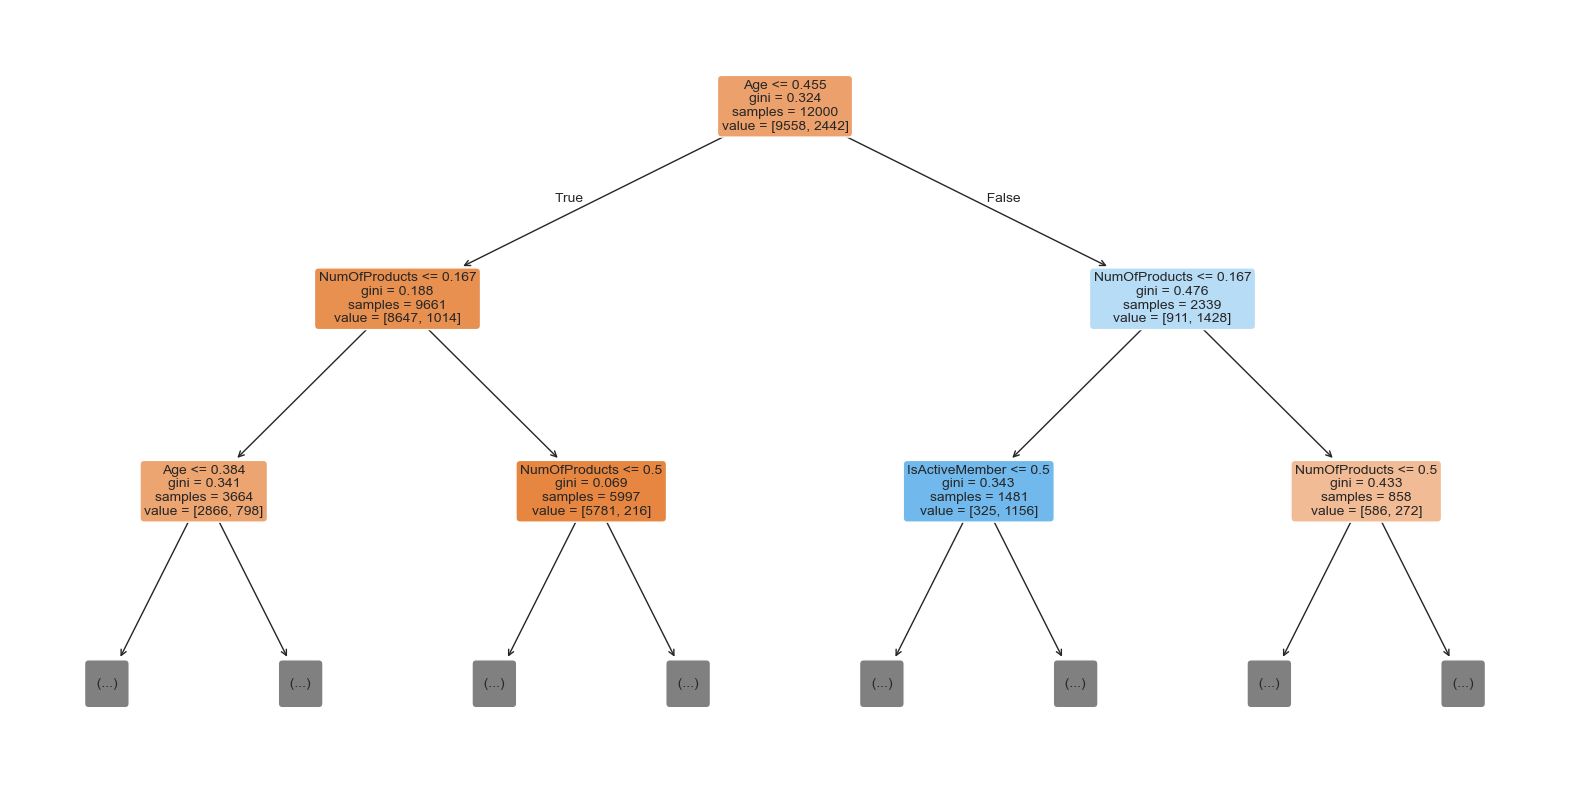

In [14]:
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X_train.columns,
    max_depth=2,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Age, NumOfProducts, IsActiveMember є найпливовішими ознаками в нашому дереві.

In [15]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- Age <= 0.38
|   |   |   |--- truncated branch of depth 24
|   |   |--- Age >  0.38
|   |   |   |--- truncated branch of depth 18
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.46
|   |--- NumOfProducts <= 0.17
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 16
|   |--- NumOfProducts >  0.17
|   |   |--- NumOfProducts <= 0.50
|   |   |   |--- truncated branch of depth 17
|   |   |--- NumOfProducts >  0.50
|   |   |   |--- class: 1.0



In [16]:
model.feature_importances_.round(2)

array([0.12, 0.36, 0.05, 0.08, 0.17, 0.01, 0.03, 0.12, 0.01, 0.01, 0.01,
       0.01, 0.01])

In [17]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [18]:
importance_df.head(10)

,feature,importance
1,Age,0.356789
4,NumOfProducts,0.168379
7,EstimatedSalary,0.123635
0,CreditScore,0.123283
3,Balance,0.079192
2,Tenure,0.052899
6,IsActiveMember,0.032688
11,Gender_Female,0.014908
9,Geography_Germany,0.014725
5,HasCrCard,0.012957


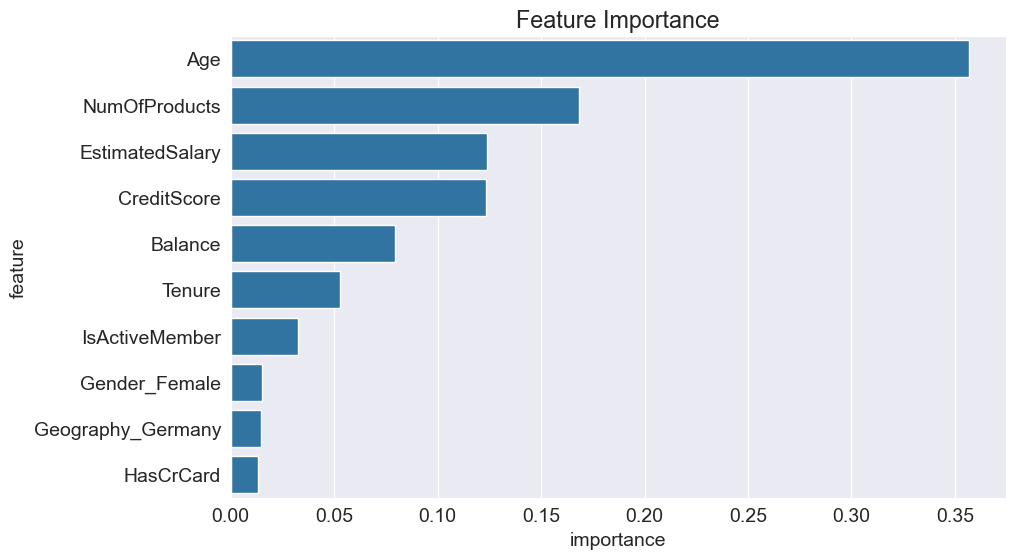

In [19]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.show();

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [20]:
def evaluate_tree(max_depth=None, max_leaf_nodes=None):
    model = DecisionTreeClassifier(
        random_state=42,
        max_depth=max_depth,
        max_leaf_nodes=max_leaf_nodes
    )
    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    val_pred = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    val_auc = roc_auc_score(y_val, val_pred)

    print(f"max_depth={max_depth}, max_leaf_nodes={max_leaf_nodes}")
    print(f"AUC train: {train_auc:.4f}")
    print(f"AUC val:   {val_auc:.4f}")
    print("-" * 40)

In [21]:
evaluate_tree(max_depth=3)

max_depth=3, max_leaf_nodes=None
AUC train: 0.8972
AUC val:   0.8911
----------------------------------------


In [22]:
evaluate_tree(max_depth=4)

max_depth=4, max_leaf_nodes=None
AUC train: 0.9113
AUC val:   0.9113
----------------------------------------


In [23]:
evaluate_tree(max_depth=5)

max_depth=5, max_leaf_nodes=None
AUC train: 0.9257
AUC val:   0.9219
----------------------------------------


In [24]:
evaluate_tree(max_depth=6)

max_depth=6, max_leaf_nodes=None
AUC train: 0.9338
AUC val:   0.9211
----------------------------------------


In [25]:
evaluate_tree(max_leaf_nodes=10)

max_depth=None, max_leaf_nodes=10
AUC train: 0.9015
AUC val:   0.9002
----------------------------------------


In [26]:
evaluate_tree(max_leaf_nodes=20)

max_depth=None, max_leaf_nodes=20
AUC train: 0.9179
AUC val:   0.9173
----------------------------------------


In [27]:
evaluate_tree(max_leaf_nodes=50)

max_depth=None, max_leaf_nodes=50
AUC train: 0.9312
AUC val:   0.9235
----------------------------------------


In [28]:
evaluate_tree(max_leaf_nodes=100)

max_depth=None, max_leaf_nodes=100
AUC train: 0.9372
AUC val:   0.9115
----------------------------------------


In [29]:
evaluate_tree(max_depth=5, max_leaf_nodes=20)

max_depth=5, max_leaf_nodes=20
AUC train: 0.9163
AUC val:   0.9160
----------------------------------------


In [30]:
evaluate_tree(max_depth=5, max_leaf_nodes=50)

max_depth=5, max_leaf_nodes=50
AUC train: 0.9257
AUC val:   0.9219
----------------------------------------


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [31]:
train_aucs = []
val_aucs = []
depths = list(range(1, 21))

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict_proba(X_train)[:, 1]
    val_pred = model.predict_proba(X_val)[:, 1]

    train_auc = roc_auc_score(y_train, train_pred)
    val_auc = roc_auc_score(y_val, val_pred)

    train_aucs.append(train_auc)
    val_aucs.append(val_auc)

    print(f"max_depth={d:2d} | AUC train={train_auc:.4f} | AUC val={val_auc:.4f}")

max_depth= 1 | AUC train=0.7447 | AUC val=0.7349
max_depth= 2 | AUC train=0.8429 | AUC val=0.8465
max_depth= 3 | AUC train=0.8972 | AUC val=0.8911
max_depth= 4 | AUC train=0.9113 | AUC val=0.9113
max_depth= 5 | AUC train=0.9257 | AUC val=0.9219
max_depth= 6 | AUC train=0.9338 | AUC val=0.9211
max_depth= 7 | AUC train=0.9415 | AUC val=0.9144
max_depth= 8 | AUC train=0.9495 | AUC val=0.9031
max_depth= 9 | AUC train=0.9591 | AUC val=0.8847
max_depth=10 | AUC train=0.9698 | AUC val=0.8484
max_depth=11 | AUC train=0.9780 | AUC val=0.8411
max_depth=12 | AUC train=0.9863 | AUC val=0.8249
max_depth=13 | AUC train=0.9920 | AUC val=0.8101
max_depth=14 | AUC train=0.9960 | AUC val=0.7948
max_depth=15 | AUC train=0.9983 | AUC val=0.7953
max_depth=16 | AUC train=0.9994 | AUC val=0.7812
max_depth=17 | AUC train=0.9998 | AUC val=0.7814
max_depth=18 | AUC train=0.9999 | AUC val=0.7830
max_depth=19 | AUC train=1.0000 | AUC val=0.7736
max_depth=20 | AUC train=1.0000 | AUC val=0.7753


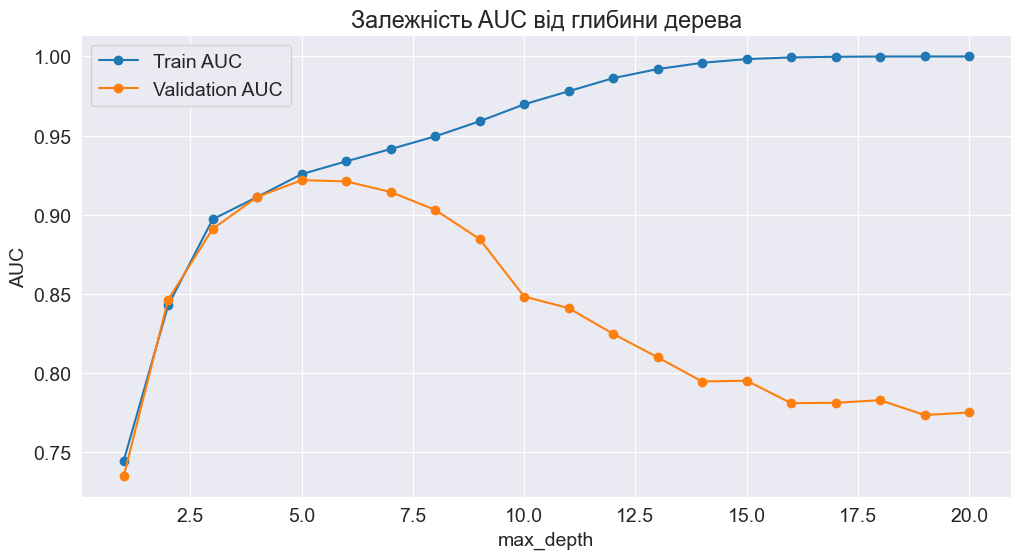

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(depths, train_aucs, marker='o', label='Train AUC')
plt.plot(depths, val_aucs, marker='o', label='Validation AUC')

plt.xlabel("max_depth")
plt.ylabel("AUC")
plt.title("Залежність AUC від глибини дерева")
plt.legend()
plt.grid(True)
plt.show()

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [33]:
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [34]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [35]:
train_pred = model.predict_proba(X_train)[:, 1]
val_pred = model.predict_proba(X_val)[:, 1]

In [36]:
print("AUC train:", roc_auc_score(y_train, train_pred))
print("AUC val:  ", roc_auc_score(y_val, val_pred))

AUC train: 0.9256944626530315
AUC val:   0.9219267439467729


In [37]:
test_df = pd.read_csv("bank_data/test.csv")
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [38]:
from bank_data.process_bank_churn import preprocess_new_data

In [39]:
X_test = preprocess_new_data(
    new_df=test_df,
    input_cols=input_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    imputer=imputer,
    scaler=scaler,
    encoder=encoder
)

In [40]:
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,0.365155,0.214286,0.2,0.696265,0.000000,1.0,1.0,0.789477,0.0,1.0,0.0,0.0,1.0
1,0.286396,0.375000,0.5,0.000000,0.333333,1.0,1.0,0.337131,1.0,0.0,0.0,0.0,1.0
2,0.656325,0.446429,0.8,0.000000,0.333333,1.0,0.0,0.783859,1.0,0.0,0.0,0.0,1.0
3,0.682578,0.482143,0.3,0.000000,0.000000,1.0,1.0,0.834571,0.0,0.0,1.0,0.0,1.0
4,0.384248,0.446429,0.8,0.000000,0.333333,1.0,1.0,0.718421,0.0,0.0,1.0,0.0,1.0


In [41]:
test_pred = model.predict_proba(X_test)[:, 1]

In [42]:
test_df['Exited'] = model.predict_proba(X_test)[:, 1]

In [43]:
test_df['Exited']

0       0.237911
1       0.027613
2       0.027613
3       0.770925
4       0.027613
          ...   
9995    0.027613
9996    0.027613
9997    0.008924
9998    0.041734
9999    0.204591
Name: Exited, Length: 10000, dtype: float64

In [44]:
submission = pd.read_csv("bank_data/sample_submission.csv")

In [45]:
submission.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [46]:
submission['Exited'] = test_df['Exited']

In [47]:
submission.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


In [48]:
submission.to_csv("bank_data/submission_tree_prun.csv", index=False)

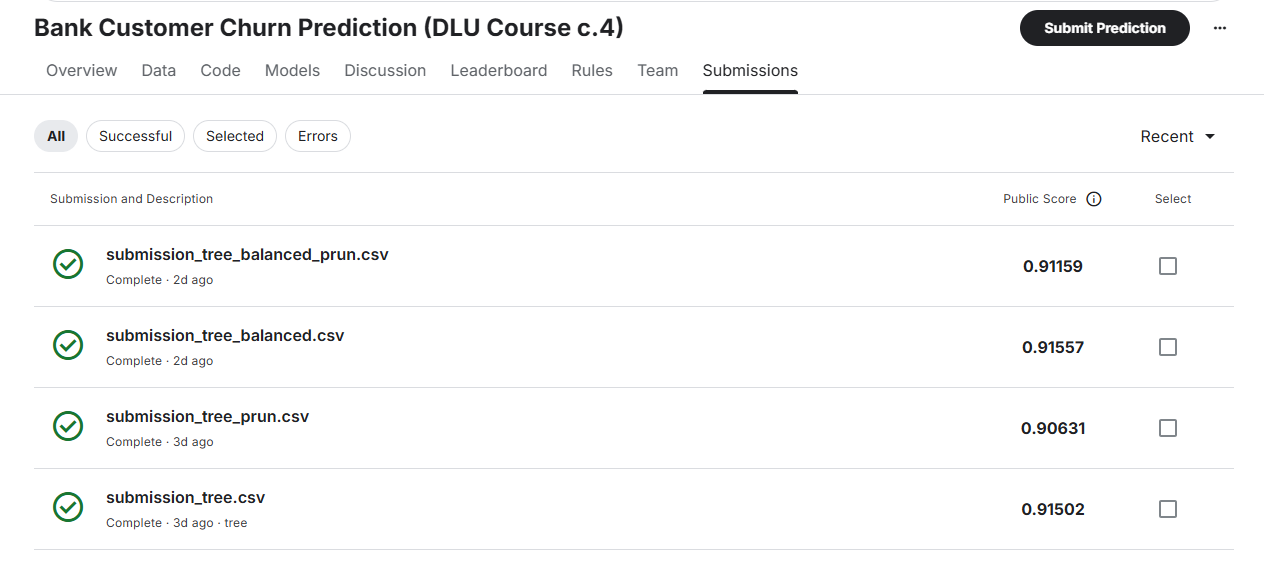

В нашому змаганні модель Дерев прийняття рішень показала гірші результати ніж логістична регресія з використанням поліномільних ознак і регуляризації, але кращі результати ніж логістична регресія без поліномільних ознак. Також Дерево з вибраною оптимальною глибиною показало себе краще ніж дерево після pruning. Додаткове балансування класів дає легке покращення результатів.

**Prunning**

In [49]:
model = DecisionTreeClassifier(random_state=42)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

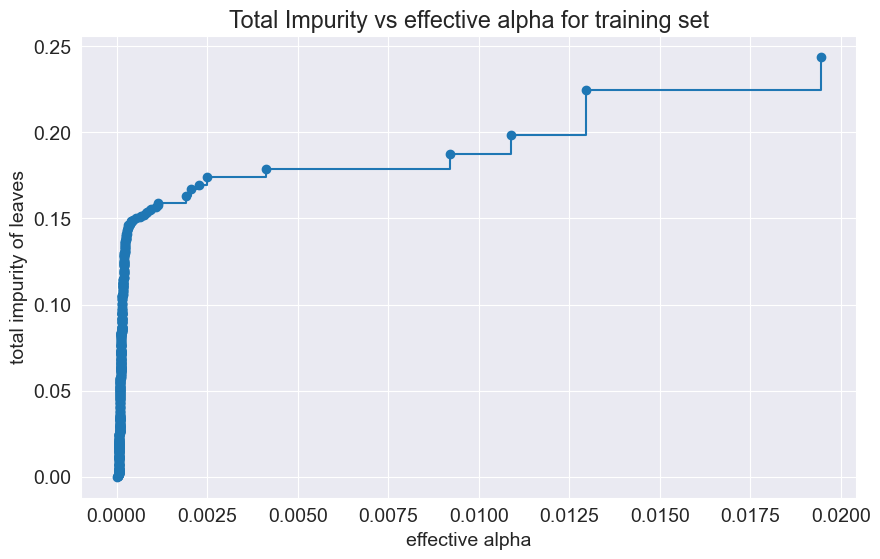

In [50]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show();

In [51]:
len(ccp_alphas)

510

In [52]:
models = []
for ccp_alpha in ccp_alphas[-10:]:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(X_train, y_train)
    models.append(model)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        models[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08021653632155293


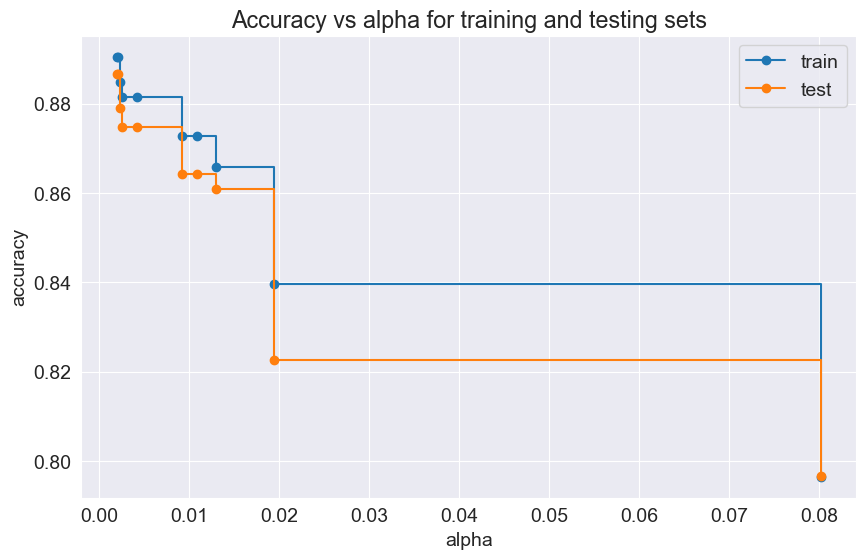

In [53]:
train_scores = [model.score(X_train, y_train) for model in models]
val_scores = [model.score(X_val, y_val) for model in models]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas[-10:], train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[-10:], val_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [54]:
model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alphas[-20])
model.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0006505363696552371),
                       random_state=42)

In [55]:
model.tree_.max_depth

8

In [56]:
model.score(X_train, y_train)

0.9025833333333333

In [57]:
model.score(X_val, y_val)

0.8956666666666667

In [58]:
train_pred = model.predict_proba(X_train)[:, 1]
val_pred = model.predict_proba(X_val)[:, 1]

In [59]:
print("AUC train:", roc_auc_score(y_train, train_pred))
print("AUC val:  ", roc_auc_score(y_val, val_pred))

AUC train: 0.9200928372303137
AUC val:   0.9192616091638659
